<a href="https://colab.research.google.com/github/Tamararoa/Aprendizaje_Automatico/blob/main/clase4/Clase4_Act2_regresion_Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Actividad 2:*

**Propósito:** Construir y evaluar un modelo de Regresión Logística para predecir el sistema operativo usado por los visitantes de un sitio web (0: Windows, 1: Macintosh, 2: Linux) en función de cuatro métricas: duración, páginas vistas, acciones y valor de las acciones.

1-Importación de librerias y carga de datos

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression


df = pd.read_csv('usuarios_win_mac_lin.csv')
df.head()


,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


2- Exploración y análisis descriptivo (EDA)

In [38]:
print (df.info ())
print (df.describe())
print(df['clase'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB
None
         duracion     paginas    acciones       valor       clase
count  170.000000  170.000000  170.000000  170.000000  170.000000
mean   111.075729    2.041176    8.723529   32.676471    0.752941
std    202.453200    1.500911    9.136054   44.751993    0.841327
min      1.000000    1.000000    1.000000    1.000000    0.000000
25%     11.000000    1.000000    3.000000    8.000000    0.000000
50%     13.000000    2.000000    6.000000   20.000000    0.000000
75%    108.000000    2.000000   10.000000   36.000000    2.000000
max    898.000000    9.000000   63.00000

3-Separacion de variables

In [39]:
# Variables independientes / características (X)
X = df[['duracion', 'paginas', 'acciones', 'valor']]

# Variable dependiente / objetivo (y)
y = df['clase']

4-Dividimos en datos de entrenamiento y prueba

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Datos de entrenamiento: {len(X_train)} filas")
print(f"Datos de evaluación: {len(X_test)} filas")

Datos de entrenamiento: 136 filas
Datos de evaluación: 34 filas


5-Entrenamiento del Modelo de REGRESIÓN LOGÍSTICA


In [41]:
log_reg_multi = LogisticRegression(max_iter=1000)
log_reg_multi.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

6-Predicciones

In [42]:
y_pred = log_reg_multi.predict(X_test)

7-Matriz de confusión

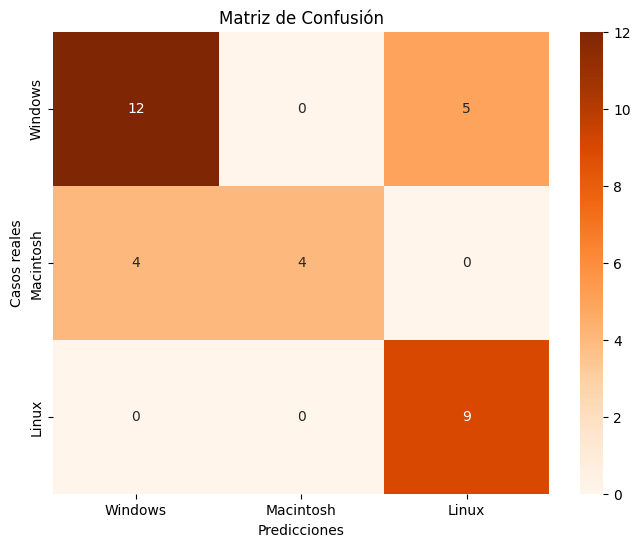

Matriz de confusión:
[[12  0  5]
 [ 4  4  0]
 [ 0  0  9]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73        17
           1       1.00      0.50      0.67         8
           2       0.64      1.00      0.78         9

    accuracy                           0.74        34
   macro avg       0.80      0.74      0.73        34
weighted avg       0.78      0.74      0.73        34



In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=['Windows', 'Macintosh', 'Linux'],
            yticklabels=['Windows', 'Macintosh', 'Linux'])

plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Casos reales')
plt.show()

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

**Análisis del Modelo de Regresion Logistica Multinomial**

*Según la matriz de confusión:*

Windows (Clase 0): 12 bien clasificados y 5 errores (confundidos como Linux).

Macintosh (Clase 1): 4 bien clasificados y 4 errores (confundidos como Windows).

Linux (Clase 2): 9 de 9 bien clasificados. Perfecto.

El modelo clasifica de excelente forma a los usuarios de Linux (capturando al 100%), muestra un desempeño aceptable con Windows y presenta dificultades para identificar a los usuarios de Macintosh (confundiendo a la mitad de ellos con usuarios de Windows).

*Reporte de Clasificación:*

Accuracy = 0.74 :El modelo acierta el 74% de los casos globales de prueba (25 de 34 casos).

Windows (0) Precisión: 0.75, Recall: 0.71 (Detecta adecuadamente al 71% de los usuarios reales de Windows, pero confunde a un 29% clasificándolos como Linux).

Macintosh (1) Precisión: 1.00, Recall: 0.50 (Cuando predice que un usuario es de Mac, acierta el 100% de las veces, pero solo logra detectar al 50% de los Mac reales, clasificando al resto como Windows).

Linux (2) Precisión: 0.64, Recall: 1.00 (Detecta al 100% de los usuarios reales de Linux, aunque incluye por error a algunos usuarios de Windows en este grupo, lo que reduce su precisión al 64%).